# **Cancellation Analysis**

## Objectives

* Answer business requirement 1:

    *The client wants to understand cancellation patterns, trends and guest booking behaviour across their portfolio in order to identify risk factors and develop more effective cancellation defence strategies*

## Inputs

* outputs/datasets/collection/HotelBookings.csv

## Outputs

* Generate code that answers business requirement 1 and can be used in future processes




---

## Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [95]:
import os
current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [96]:
os.chdir(os.path.dirname(current_dir))

current_dir = os.getcwd()
current_dir

'/home/niall/PP4'

## Load Data

In [97]:
import pandas as pd
df = pd.read_csv("outputs/datasets/collection/HotelBookings.csv")
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
1,Resort Hotel,0,737,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
2,Resort Hotel,0,7,2023,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02


* Remove `reservation_status` and `reservation_status_date` due to data leak against target variable.

In [98]:
df = df.drop(columns=["reservation_status", "reservation_status_date"])
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2023,July,27,1,0,0,2,...,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2023,July,27,1,0,0,2,...,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2023,July,27,1,0,1,1,...,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0


## Dataset Overview

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

* The dataset comprises 119390 rows across 30 features.

In [100]:
from ydata_profiling import ProfileReport
profile_report = ProfileReport(df, minimal=True)
profile_report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

* The dataset overview shows 3.6% missing cells and all dtypes are int64, float64 or object.

---

## Target Variable Analysis

**Cancellation Distibution**

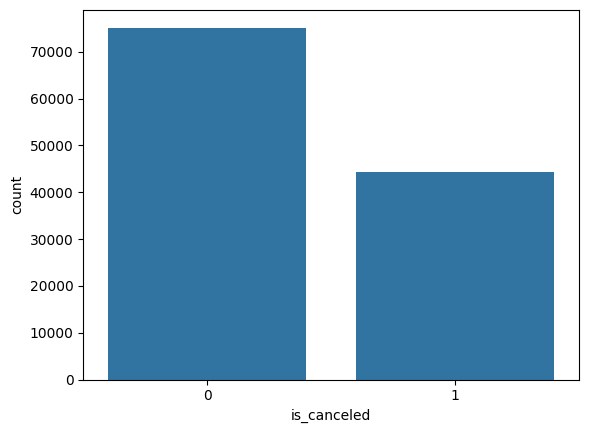

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.countplot(data=df,
              x="is_canceled")
plt.show()

* The plot shows a moderate class imbalance, the following steps evaluate that further:

In [102]:
target = df["is_canceled"]
cxl_df = pd.DataFrame({"Value": target.unique(),
                       "Frequency": target.value_counts().reset_index(drop=True),
                       "Percentage": target.value_counts(normalize=True)})

cxl_df.style.bar(subset=["Percentage"], color="darkgreen").format({"Percentage": "{:.0%}"})

,Value,Frequency,Percentage
0,0,75166,63%
1,1,44224,37%


* The overall cancellation rate is 37% indicating a moderate class imbalance that will require consideration during modelling.

**Cancellation by hotel type**

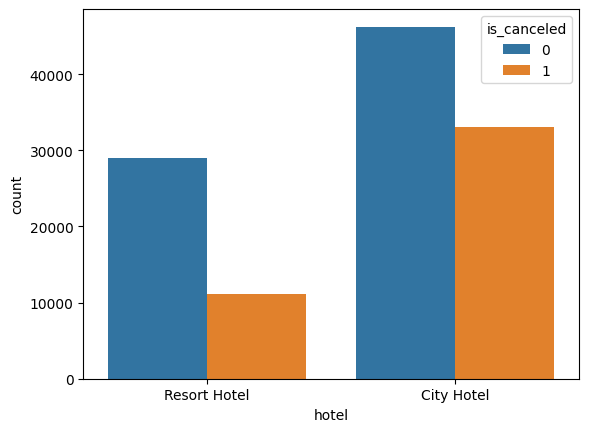

In [103]:
sns.countplot(data=df,
              x="hotel",
              hue="is_canceled")
plt.show()

* The city hotel shows both more bookings and more cancellations that the resort hotel. The city hotel appears to have a higher cancellation rate than the resort hotel.

In [104]:
df_by_hotel = pd.DataFrame({"cancellations": target.groupby(df["hotel"]).sum(),
                            "total_bookings": target.groupby(df["hotel"]).size()}).reset_index()
df_by_hotel["cancellation_rate"] = df_by_hotel["cancellations"] / df_by_hotel["total_bookings"]
df_by_hotel["percentage_of_total_cancellations"] = df_by_hotel["cancellations"] / df_by_hotel["cancellations"].sum()

df_by_hotel.drop(columns=["total_bookings"]).style.bar(
    subset=["cancellation_rate", "percentage_of_total_cancellations"], 
    color="darkgreen").format({"cancellation_rate": "{:.0%}","percentage_of_total_cancellations": "{:.0%}"})

,hotel,cancellations,cancellation_rate,percentage_of_total_cancellations
0,City Hotel,33102,42%,75%
1,Resort Hotel,11122,28%,25%


* This confirms that the city hotel has a higher percentage of cancellations compared to the resort hotel. This is, in part, offset by the increase in total bookings. While the city hotel accounts for 75% of all cancellations, their cancellation rate is 42% - only slightly higer than the overall cancellation rate of 37%, but significantly higher statistically than the resort hotel at 28%

**Periodicity Study**

* Check date dtypes

In [105]:
df[["arrival_date_year", "arrival_date_month"]].dtypes

arrival_date_year      int64
arrival_date_month    object
dtype: object

* Change month dtype to categorical to maintain calendar order

In [106]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"], categories=month_order, ordered=True)
df[["arrival_date_year", "arrival_date_month"]].dtypes

arrival_date_year        int64
arrival_date_month    category
dtype: object

* Prepare monthly and yearly cancellation rates for plotting

In [107]:
df_by_year = pd.DataFrame({"year": df["arrival_date_year"].unique(),
                           "cancellation_rate": target
                           .groupby(df["arrival_date_year"])
                           .mean()
                           .reset_index(drop=True)
                           })
df_by_year.style.format({"cancellation_rate": "{:.0%}"})

,year,cancellation_rate
0,2023,37%
1,2024,36%
2,2025,39%


In [108]:

df_by_month = pd.DataFrame({"cancellation_rate": target
                           .groupby([df["arrival_date_year"], df["arrival_date_month"]], observed=True)
                           .mean()
                           })
df_by_month.style.format({"cancellation_rate": "{:.0%}"})

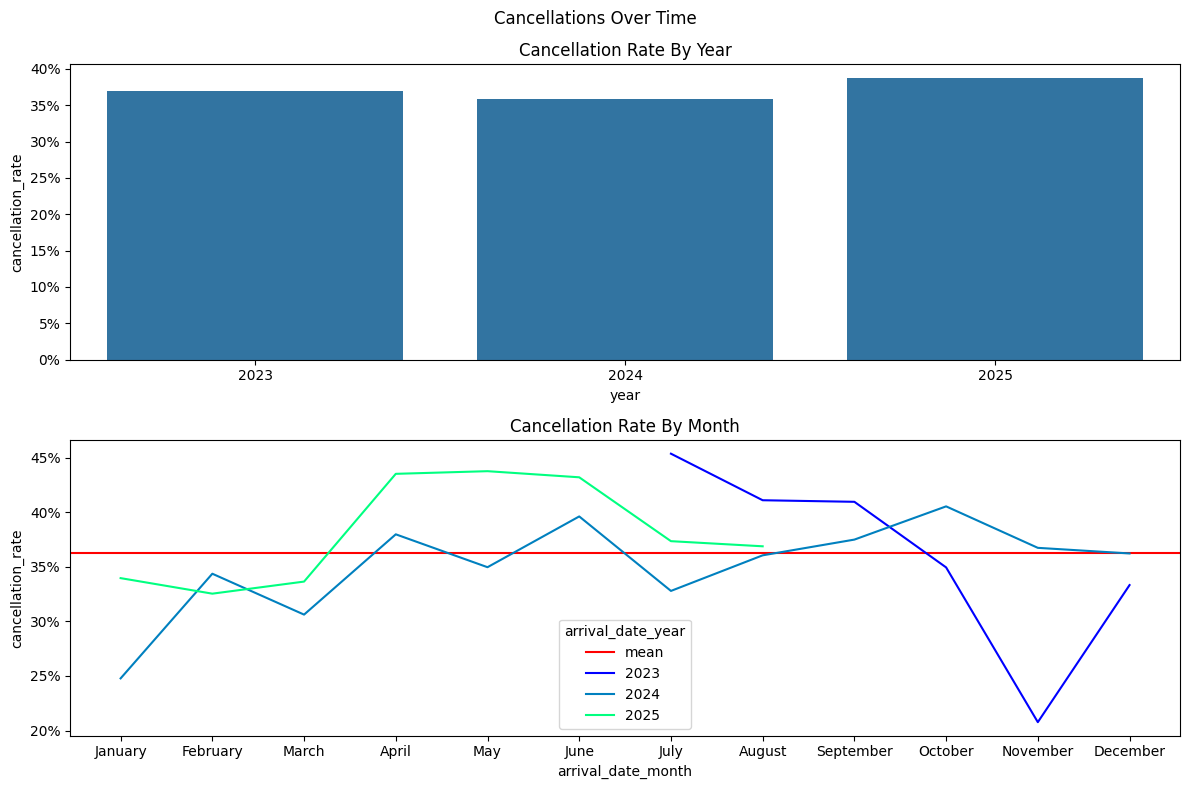

In [119]:
import matplotlib.ticker as mticker

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("Cancellations Over Time")
ax1.set_title("Cancellation Rate By Year")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.set_title("Cancellation Rate By Month")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.axhline(df_by_month["cancellation_rate"].mean(), color="red", label="mean")

sns.barplot(data=df_by_year,
            x="year",
            y="cancellation_rate",
            ax=ax1)

sns.lineplot(data=df_by_month,
             x="arrival_date_month",
             y="cancellation_rate",
             hue="arrival_date_year",
             palette="winter",
             ax=ax2)

plt.tight_layout()
plt.show()

* The cancellation rate per year is very balanced
* The cancellation rate per month shows some patterns worth further exploration, though the incomplete nature of 2023 and 2025 make it difficult to draw any definitive conclusions.

---

## Feature Analysis

* Visualise 

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In case you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [110]:
import os
try:
  # create here your folder
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (2852421808.py, line 5)